<a href="https://colab.research.google.com/github/vivianlinnn/DS41_IDXExchange/blob/main/src/08_LightGBM_EvaluationRange_Team.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LightGBM Evaluation by Price Range
## START: LEXI CHEN

This notebook evaluates **price ranges based on `LogClosePrice`** and also converts each log-price interval back into an approximate **close-price dollar range**.

### What this notebook does
1. Loads the processed training and test data.
2. Rebuilds the same LightGBM model setup from the team notebook.
3. Generates test-set predictions.
4. Creates **log-price ranges** such as `[12, 13)`, `[13, 14)`, etc.
5. Converts those ranges back to **close-price intervals** using `exp()`.
6. Computes range-wise metrics such as:
   - Count
   - Average actual price
   - Average predicted price
   - MAPE
   - MdAPE
   - RMSE
7. Saves the final output to CSV for reporting.


## 1. Import Libraries

We import the same core libraries used in the LightGBM workflow:
- `pandas` and `numpy` for data handling
- `lightgbm` for the regression model
- `pathlib` for flexible file loading
- `matplotlib` for visualization
- `sklearn` metrics for evaluation


In [1]:
!pip -q install lightgbm

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

## 2. Load Training and Test Data


In [5]:
import pandas as pd

# Load training and test data
train = pd.read_csv('/content/train_cleaned_fe.csv')
test  = pd.read_csv('/content/test_cleaned_fe.csv')

print("Train shape:", train.shape)
print("Test shape :", test.shape)

Train shape: (67727, 31)
Test shape : (10324, 31)


## 3. Recreate the Team's LightGBM Setup

In [6]:
numeric_cols = [
    'LivingArea', 'BedroomsTotal', 'LotSizeSquareFeet',
    'BathroomsTotalInteger', 'Bed_Bath_Ratio',
    'Property_Age', 'Months_From_Dec_2025'
]

for df in [train, test]:
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

train = train.dropna(subset=['ClosePrice']).copy()
test = test.dropna(subset=['ClosePrice']).copy()

train['LogClosePrice'] = np.log(train['ClosePrice'])
test['LogClosePrice'] = np.log(test['ClosePrice'])

for df in [train, test]:
    df['BedroomsTotal'] = df['BedroomsTotal'].replace(0, np.nan)
    df['LotSizeSquareFeet'] = df['LotSizeSquareFeet'].replace(0, np.nan)
    df['Sqft_Per_Bedroom'] = df['LivingArea'] / df['BedroomsTotal']
    df['Lot_Utilization'] = df['LivingArea'] / df['LotSizeSquareFeet']

In [7]:
zip_median = train.groupby('PostalCode')['LogClosePrice'].median()
train['ZipMedianPrice'] = train['PostalCode'].map(zip_median)
test['ZipMedianPrice'] = test['PostalCode'].map(zip_median)

global_median = train['LogClosePrice'].median()
test['ZipMedianPrice'] = test['ZipMedianPrice'].fillna(global_median)

tree_features = [
    'ZipMedianPrice', 'LivingArea', 'BathroomsTotalInteger',
    'BedroomsTotal', 'Bed_Bath_Ratio', 'Property_Age',
    'Months_From_Dec_2025', 'Sqft_Per_Bedroom', 'Lot_Utilization'
]

for df in [train, test]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=tree_features + ['LogClosePrice'], inplace=True)

X_train = train[tree_features]
y_train = train['LogClosePrice']
X_test = test[tree_features]
y_test = test['LogClosePrice']

lgbm_model = LGBMRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

lgbm_model.fit(X_train, y_train)

train_pred_log = lgbm_model.predict(X_train)
test_pred_log = lgbm_model.predict(X_test)

train_pred_price = np.exp(train_pred_log)
test_pred_price = np.exp(test_pred_log)

y_train_price = np.exp(y_train)
y_test_price = np.exp(y_test)

print("Train R²:", round(r2_score(y_train, train_pred_log), 4))
print("Test R² :", round(r2_score(y_test, test_pred_log), 4))
print("Test MAPE (%):", round(mean_absolute_percentage_error(y_test_price, test_pred_price) * 100, 2))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003200 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1236
[LightGBM] [Info] Number of data points in the train set: 67669, number of used features: 9
[LightGBM] [Info] Start training from score 13.773877
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

## 4. Build the Evaluation Table

We create a test-set table with:
- actual log price
- predicted log price
- actual close price
- predicted close price
- absolute percentage error

This makes it easy to analyze model behavior by range.


In [8]:
eval_df = pd.DataFrame({
    'Actual_LogClosePrice': y_test.values,
    'Predicted_LogClosePrice': test_pred_log,
    'ClosePrice': y_test_price.values,
    'Predicted_Price': test_pred_price
})

eval_df['Absolute_Percentage_Error'] = (
    np.abs(eval_df['ClosePrice'] - eval_df['Predicted_Price']) / eval_df['ClosePrice'] * 100
)

eval_df.head()

,Actual_LogClosePrice,Predicted_LogClosePrice,ClosePrice,Predicted_Price,Absolute_Percentage_Error
0,14.507657,14.245227,1998000.0,1.536821e+06,23.082020
1,14.610502,14.452340,2214421.0,1.890478e+06,14.628775
2,13.997832,14.028448,1200000.0,1.237307e+06,3.108919
3,14.946913,14.679657,3100000.0,2.372979e+06,23.452295
4,14.880221,14.599458,2900000.0,2.190099e+06,24.479328


## 5. Define Log-Price Ranges and Convert Them Back to Close Price

Here we create unit-width bins such as:
- `[12, 13)`
- `[13, 14)`
- `[14, 15)`

Then we convert each interval back to dollar scale:
- `[exp(12), exp(13))`
- `[exp(13), exp(14))`
- etc.

This directly matches the idea:  
**Ranges in `LogClosePrice` → convert back to `ClosePrice`.**


In [9]:
# Create 1-unit bins based on the actual LogClosePrice distribution in the test set
min_edge = int(np.floor(eval_df['Actual_LogClosePrice'].min()))
max_edge = int(np.ceil(eval_df['Actual_LogClosePrice'].max()))

# Ensure at least one full interval and include the upper edge
bins = list(range(min_edge, max_edge + 1))
if len(bins) < 2:
    bins = [min_edge, min_edge + 1]

def log_range_label(left, right):
    return f"[{left}, {right})"

def close_price_range_label(left, right):
    low = np.exp(left)
    high = np.exp(right)
    return f"[${low:,.0f}, ${high:,.0f})"

log_labels = [log_range_label(bins[i], bins[i+1]) for i in range(len(bins) - 1)]

eval_df['LogClosePrice_Range'] = pd.cut(
    eval_df['Actual_LogClosePrice'],
    bins=bins,
    labels=log_labels,
    right=False,
    include_lowest=True
)

range_lookup = pd.DataFrame({
    'LogClosePrice_Range': log_labels,
    'ClosePrice_Range': [close_price_range_label(bins[i], bins[i+1]) for i in range(len(bins) - 1)]
})

range_lookup

,LogClosePrice_Range,ClosePrice_Range
0,"[12, 13)","[$162,755, $442,413)"
1,"[13, 14)","[$442,413, $1,202,604)"
2,"[14, 15)","[$1,202,604, $3,269,017)"
3,"[15, 16)","[$3,269,017, $8,886,111)"


## 6. Compute Range-wise Evaluation Metrics

We evaluate each actual log-price range separately. This helps answer questions like:
- Does the model perform better on lower-priced homes?
- Does error grow in more expensive ranges?
- Are some ranges underrepresented?


In [10]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def mdape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.median(np.abs((y_true - y_pred) / y_true)) * 100

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

range_analysis = (
    eval_df
    .groupby('LogClosePrice_Range', observed=False)
    .apply(lambda x: pd.Series({
        'Count': len(x),
        'Avg_Actual_Price': x['ClosePrice'].mean(),
        'Avg_Predicted_Price': x['Predicted_Price'].mean(),
        'MAPE (%)': mape(x['ClosePrice'], x['Predicted_Price']),
        'MdAPE (%)': mdape(x['ClosePrice'], x['Predicted_Price']),
        'RMSE': rmse(x['ClosePrice'], x['Predicted_Price'])
    }))
    .reset_index()
)

range_analysis = range_analysis.merge(range_lookup, on='LogClosePrice_Range', how='left')

range_analysis = range_analysis[[
    'LogClosePrice_Range',
    'ClosePrice_Range',
    'Count',
    'Avg_Actual_Price',
    'Avg_Predicted_Price',
    'MAPE (%)',
    'MdAPE (%)',
    'RMSE'
]]

range_analysis

/tmp/ipykernel_7718/1788174596.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,LogClosePrice_Range,ClosePrice_Range,Count,Avg_Actual_Price,Avg_Predicted_Price,MAPE (%),MdAPE (%),RMSE
0,"[12, 13)","[$162,755, $442,413)",1071.0,3.538690e+05,4.066784e+05,20.761589,12.362700,1.061133e+05
1,"[13, 14)","[$442,413, $1,202,604)",6158.0,7.775714e+05,8.047805e+05,12.798229,9.029344,1.505104e+05
2,"[14, 15)","[$1,202,604, $3,269,017)",2709.0,1.776109e+06,1.714737e+06,16.094917,12.641889,4.119427e+05
3,"[15, 16)","[$3,269,017, $8,886,111)",376.0,4.703583e+06,3.918448e+06,22.287230,19.815565,1.498198e+06


## 7. Visualize Average Actual vs Predicted Price by Range


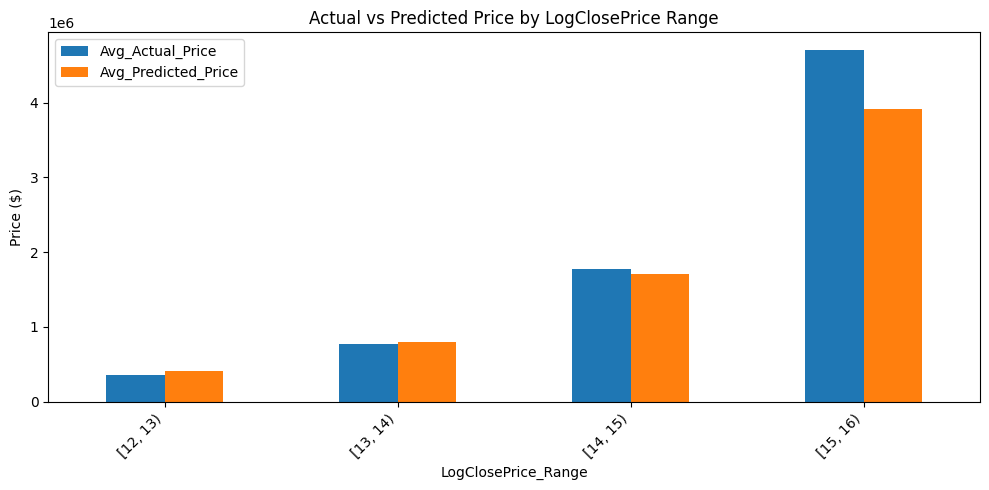

In [11]:
plot_df = range_analysis.set_index('LogClosePrice_Range')[['Avg_Actual_Price', 'Avg_Predicted_Price']]
plot_df.plot(kind='bar', figsize=(10, 5))
plt.title('Actual vs Predicted Price by LogClosePrice Range')
plt.ylabel('Price ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The results show that model performance varies across different price ranges, with the most accurate predictions occurring in the mid-price segment. In the lower price range ([12, 13)), the model tends to overpredict, as seen by the higher average predicted price compared to the actual price, resulting in a relatively high MAPE (~20.8%). Performance improves significantly in the [13, 14) range, where both MAPE (~12.8%) and MdAPE (~9.0%) are the lowest, indicating that the model is best calibrated for moderately priced properties.

As prices increase further, the model begins to underpredict, particularly in the higher ranges. In the [14, 15) range, errors increase moderately, while in the highest range ([15, 16)), the model shows the poorest performance, with the highest MAPE (~22.3%) and RMSE. This is also reflected in the plot, where the gap between actual and predicted prices widens at the high end. The decline in performance at higher prices is likely due to fewer data points and greater variability in expensive properties. Overall, the model performs best in the mid-range, struggles with overestimation at the low end, and becomes less reliable for high-value properties.

# END: LEXI CHEN

# Start: Anjali Manju Gowda

In [12]:
train_eval = pd.DataFrame({
    'Actual_Log': y_train.values,
    'Predicted_Log': train_pred_log,
    'Actual_Price': y_train_price.values,
    'Predicted_Price': train_pred_price
})
test_eval = pd.DataFrame({
    'Actual_Log': y_test.values,
    'Predicted_Log': test_pred_log,
    'Actual_Price': y_test_price.values,
    'Predicted_Price': test_pred_price
})

# DEFINE FIXED LOG RANGES

bins = [12, 13, 14, 15, 16]
labels = ['[12-13)', '[13-14)', '[14-15)', '[15-16)']

train_eval['Range'] = pd.cut(train_eval['Actual_Log'], bins=bins, labels=labels)
test_eval['Range']  = pd.cut(test_eval['Actual_Log'], bins=bins, labels=labels)

# METRIC FUNCTIONS

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def mdape(y_true, y_pred):
    return np.median(np.abs((y_true - y_pred) / y_true)) * 100

def compute_metrics(df):
    return df.groupby('Range', observed=False).apply(
        lambda x: pd.Series({
            'R2': r2_score(x['Actual_Price'], x['Predicted_Price']),
            'R2_Log': r2_score(x['Actual_Log'], x['Predicted_Log']),
            'MAPE (%)': mape(x['Actual_Price'], x['Predicted_Price']),
            'MdAPE (%)': mdape(x['Actual_Price'], x['Predicted_Price'])
        })
    )

train_metrics = compute_metrics(train_eval).rename(columns={
    'R2': 'Train R2',
    'R2_Log': 'Train R2 (Log)',
    'MAPE (%)': 'Train MAPE (%)',
    'MdAPE (%)': 'Train MdAPE (%)'
})

test_metrics = compute_metrics(test_eval).rename(columns={
    'R2': 'Test R2',
    'R2_Log': 'Test R2 (Log)',
    'MAPE (%)': 'Test MAPE (%)',
    'MdAPE (%)': 'Test MdAPE (%)'
})

# MERGE BOTH RESULTS

final_table = train_metrics.join(test_metrics).reset_index()

print(final_table)

final_table.to_csv('/content/lightgbm_range_full_metrics.csv', index=False)

     Range  Train R2  Train R2 (Log)  Train MAPE (%)  Train MdAPE (%)  \
0  [12-13) -0.974075       -0.180904       16.955706        10.502680   
1  [13-14)  0.547144        0.669395       11.559712         8.390447   
2  [14-15)  0.474710        0.431183       14.572240        11.884586   
3  [15-16)  0.019750       -0.657695       19.203491        16.437272   

    Test R2  Test R2 (Log)  Test MAPE (%)  Test MdAPE (%)  
0 -1.823101      -0.601990      20.761589       12.362700  
1  0.428645       0.585362      12.798229        9.029344  
2  0.332132       0.254902      16.094917       12.641889  
3 -0.240863      -1.207937      22.287230       19.815565  


/tmp/ipykernel_7718/1510645554.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('Range', observed=False).apply(
/tmp/ipykernel_7718/1510645554.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('Range', observed=False).apply(


# END: Anjali Manju Gowda

